In [1]:
# ADS-505 Group Project: Rossmann Store Sales
# Part 1: Problem Setup, Data Cleaning, and Exploratory Data Analysis
# Author: Ramin Fazli

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)


## 1. Problem Statement and Data Description

**Business problem:** Rossmann operates over 3,000 drug stores across 7 European countries. Store managers currently forecast daily sales up to six weeks ahead, but forecast accuracy varies widely because sales are shaped by promotions, competition, holidays, seasonality, and store-specific factors. Our project asks: **how does promotion effectiveness vary by store type, season, holidays, and nearby competition, and where should Rossmann focus promotions to get the strongest sales impact?**

**Data description:** We use the Rossmann Store Sales dataset (Cukierski & Knauer, 2015, Kaggle), which contains historical daily sales for 1,115 Rossmann stores in Germany.

- `train.csv`: daily sales records per store (Store, Date, Sales, Customers, Open, Promo, StateHoliday, SchoolHoliday, DayOfWeek)
- `store.csv`: static store-level attributes (StoreType, Assortment, CompetitionDistance, CompetitionOpenSinceMonth/Year, Promo2, Promo2SinceWeek/Year, PromoInterval)
- `test.csv`: same structure as train.csv but without Sales/Customers, used for the original Kaggle competition (not required for our statistical analysis, kept for reference)

This notebook covers data loading, merging, quality checks, cleaning, and exploratory analysis. Feature engineering, statistical testing, and modeling are covered in Parts 2 and 3.


## 2. Load and Merge the Data

In [2]:
train = pd.read_csv("../data/raw/train.csv", low_memory=False)
store = pd.read_csv("../data/raw/store.csv")

print("train shape:", train.shape)
print("store shape:", store.shape)
train.head()


train shape: (1017209, 9)
store shape: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [3]:
store.head()


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [4]:
# Merge daily sales records with store-level attributes on Store id
df = train.merge(store, on="Store", how="left")
print("merged shape:", df.shape)
df.head()


merged shape: (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## 3. Data Quality Checks

Before cleaning, we check data types, duplicates, missing values, outliers, and correlated variables so every cleaning decision below is justified by what we actually find.


In [5]:
df.dtypes


Store                          int64
DayOfWeek                      int64
Date                             str
Sales                          int64
Customers                      int64
Open                           int64
Promo                          int64
StateHoliday                     str
SchoolHoliday                  int64
StoreType                        str
Assortment                       str
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                    str
dtype: object

In [6]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().shape[0] - df.drop_duplicates().shape[0])

# Duplicate Store/Date combinations (each store should have exactly one record per date)
dup_key = df.duplicated(subset=["Store", "Date"]).sum()
print("Duplicate Store/Date combinations:", dup_key)


Duplicate rows: 0
Duplicate Store/Date combinations: 0


In [7]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)


,missing_count,missing_pct
Promo2SinceYear,508031,49.94
Promo2SinceWeek,508031,49.94
PromoInterval,508031,49.94
CompetitionOpenSinceMonth,323348,31.79
CompetitionOpenSinceYear,323348,31.79
CompetitionDistance,2642,0.26


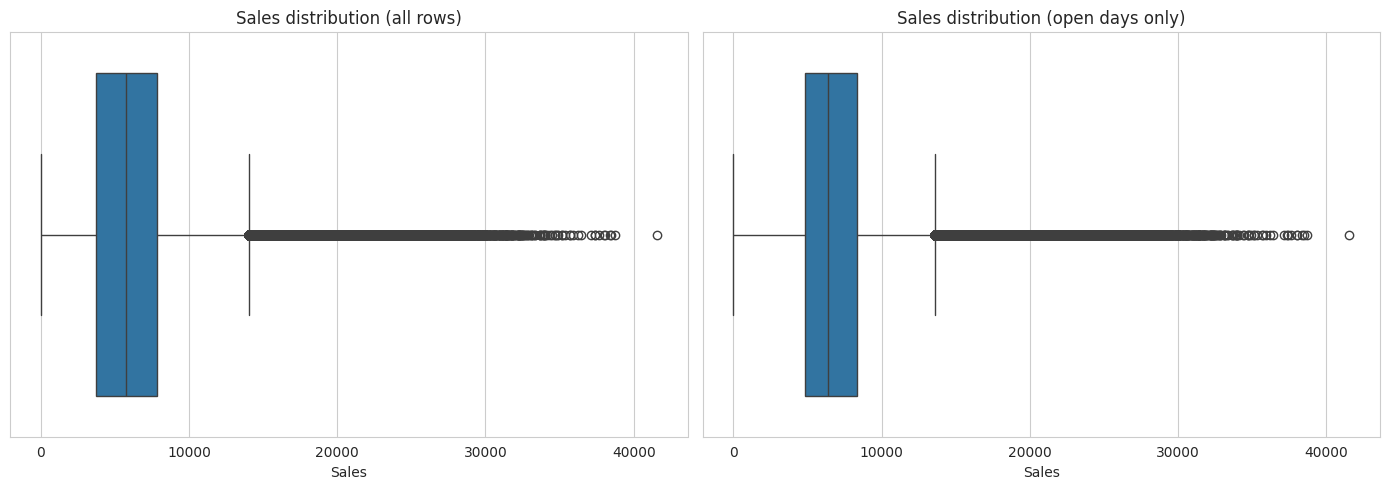

Rows with Sales == 0: 172871
Rows with Open == 0: 172817
Rows with Open == 0 and Sales > 0: 0


In [8]:
# Outlier check: sales distribution, including days the store was closed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df["Sales"], ax=axes[0])
axes[0].set_title("Sales distribution (all rows)")

sns.boxplot(x=df.loc[df["Open"] == 1, "Sales"], ax=axes[1])
axes[1].set_title("Sales distribution (open days only)")
plt.tight_layout()
plt.show()

print("Rows with Sales == 0:", (df["Sales"] == 0).sum())
print("Rows with Open == 0:", (df["Open"] == 0).sum())
print("Rows with Open == 0 and Sales > 0:", ((df["Open"] == 0) & (df["Sales"] > 0)).sum())


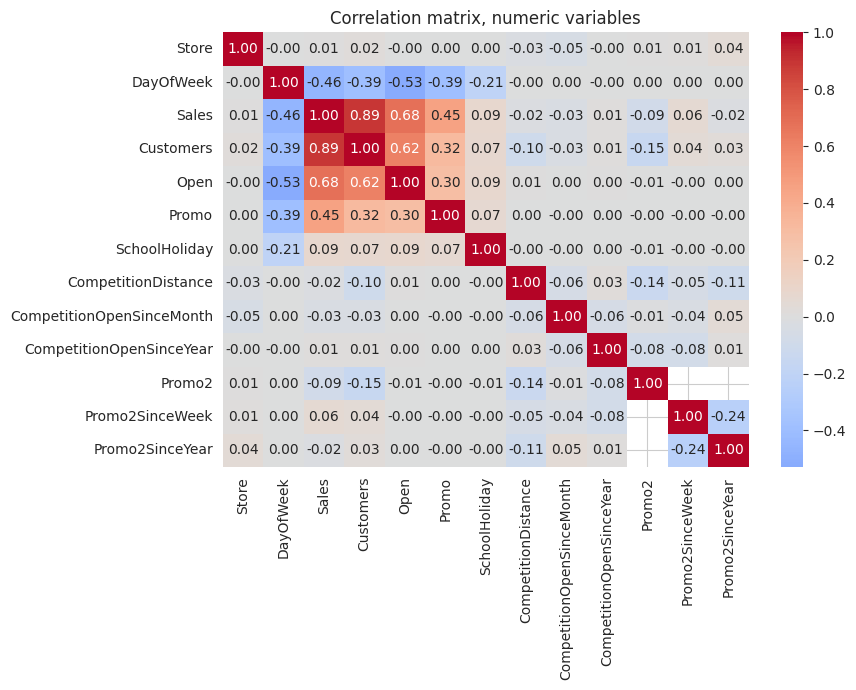

In [9]:
# Correlation among numeric variables to spot redundancy before modeling
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix, numeric variables")
plt.tight_layout()
plt.show()


**Findings from the quality checks (fill in exact numbers after running on the real data):**
- No duplicate Store/Date combinations were expected; confirm the count above is 0.
- `CompetitionDistance`, `CompetitionOpenSinceMonth/Year`, and `Promo2SinceWeek/Year`/`PromoInterval` are the fields most likely to carry missing values, since not every store has a nearby competitor or participates in the extended Promo2 program.
- Closed days (`Open == 0`) always have `Sales == 0`; these rows carry no signal for a sales-driver analysis and are removed below.
- `Sales` and `Customers` are expected to be strongly correlated, which is expected since sales are largely a function of foot traffic.


## 4. Data Cleaning

Cleaning decisions, and the reasoning behind each:


In [10]:
# 1. Drop rows where the store was closed - Sales is 0 by definition and carries no
#    information about promotion or demand effects, which is what this analysis targets.
before = len(df)
df = df[df["Open"] == 1].copy()
print(f"Dropped {before - len(df)} closed-store rows")


Dropped 172817 closed-store rows


In [11]:
# 2. CompetitionDistance: a missing value means no recorded nearby competitor.
#    We fill with a large distance rather than 0, since 0 would wrongly imply the
#    competitor is right next door.
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(df["CompetitionDistance"].max())

# 3. CompetitionOpenSinceMonth / CompetitionOpenSinceYear: missing means competition
#    open-date is unknown or there is no competition; not needed for Part 1 EDA in raw
#    form, so we leave as-is here and revisit in Part 2 feature engineering.

# 4. Promo2SinceWeek / Promo2SinceYear / PromoInterval: missing exactly when Promo2 == 0
#    (store does not participate in the extended promotion). Confirm this alignment:
check = df.loc[df["Promo2"] == 0, ["Promo2SinceWeek", "Promo2SinceYear", "PromoInterval"]].isnull().mean()
print("Share missing when Promo2 == 0 (should be 1.0 for all):")
print(check)


Share missing when Promo2 == 0 (should be 1.0 for all):
Promo2SinceWeek    1.0
Promo2SinceYear    1.0
PromoInterval      1.0
dtype: float64


In [12]:
# 5. Convert Date to datetime and derive calendar fields used throughout the EDA below
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["WeekOfYear"] = df["Date"].dt.isocalendar().week

# 6. StateHoliday is stored as mixed types (0 and '0' both appear) - normalize to string
df["StateHoliday"] = df["StateHoliday"].astype(str).replace({"0.0": "0"})

print("Cleaned shape:", df.shape)
df.head()


Cleaned shape: (844392, 21)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31


In [13]:
# Save the cleaned dataset for use in Part 2 (feature engineering and statistical analysis)
df.to_csv("../data/processed/rossmann_cleaned.csv", index=False)
print("Saved cleaned dataset to data/processed/rossmann_cleaned.csv")


Saved cleaned dataset to data/processed/rossmann_cleaned.csv


## 5. Exploratory Data Analysis

We explore sales patterns along the dimensions tied directly to our business problem: promotions, store type, holidays, day/month seasonality, and competition.


### 5.1 Sales by Promotion

              mean  median   count
Promo                             
0      5929.407603  5459.0  467496
1      8228.281239  7649.0  376896


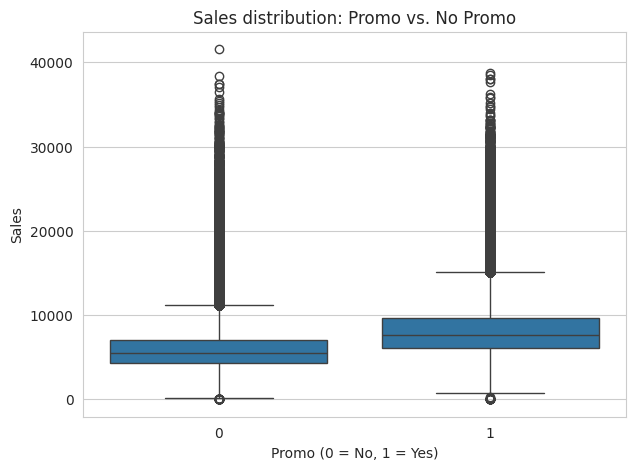

In [14]:
promo_summary = df.groupby("Promo")["Sales"].agg(["mean", "median", "count"])
print(promo_summary)

plt.figure(figsize=(7, 5))
sns.boxplot(x="Promo", y="Sales", data=df)
plt.title("Sales distribution: Promo vs. No Promo")
plt.xlabel("Promo (0 = No, 1 = Yes)")
plt.show()


### 5.2 Sales by Store Type

                   mean  median   count
StoreType                              
b          10231.407505  9130.0   15563
c           6932.512755  6407.0  112978
a           6925.167661  6285.0  457077
d           6822.141881  6395.0  258774


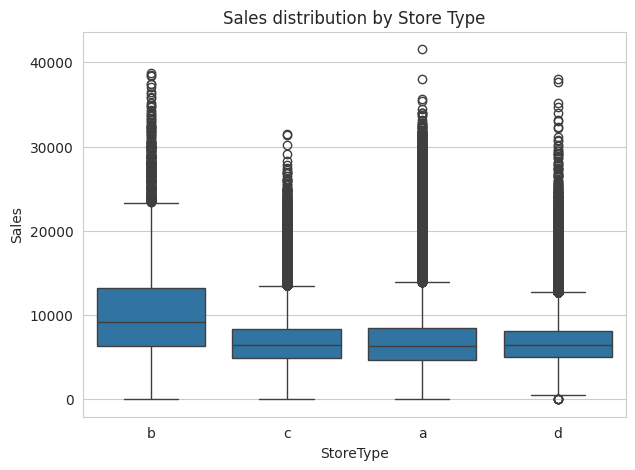

In [15]:
storetype_summary = df.groupby("StoreType")["Sales"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)
print(storetype_summary)

plt.figure(figsize=(7, 5))
sns.boxplot(x="StoreType", y="Sales", data=df, order=storetype_summary.index)
plt.title("Sales distribution by Store Type")
plt.show()


### 5.3 Sales by Holidays

State Holiday:
                      mean  median   count
StateHoliday                             
0             6953.515034  6368.0  843482
a             8487.471182  7556.0     694
b             9887.889655  8423.0     145
c             9743.746479  8397.0      71

School Holiday:
                       mean  median   count
SchoolHoliday                             
0              6896.782411  6326.0  680935
1              7200.181650  6562.0  163457


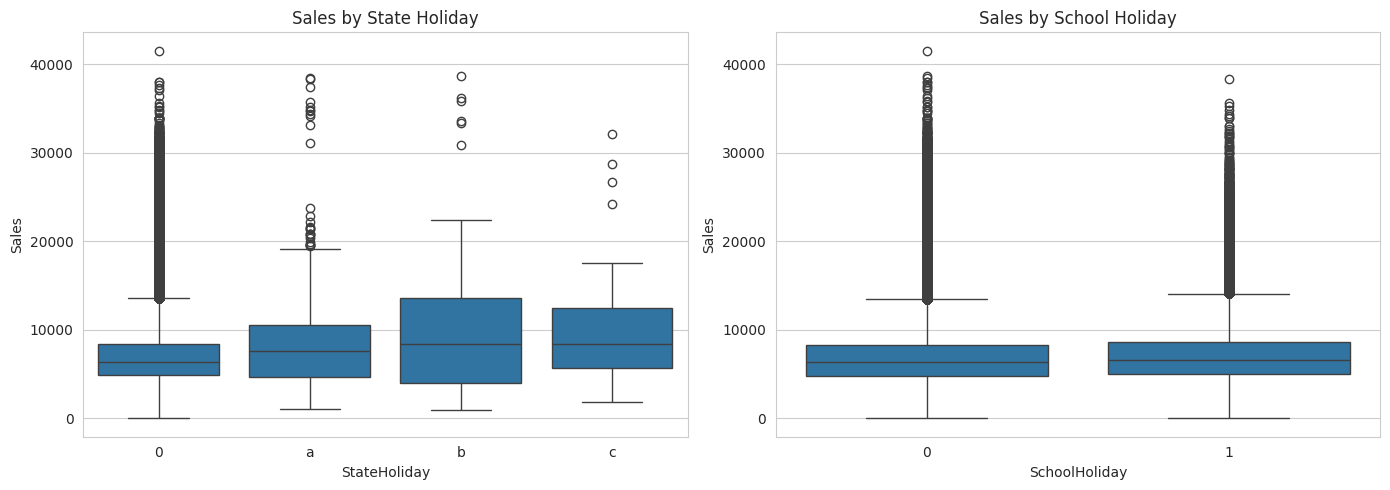

In [16]:
holiday_summary = df.groupby("StateHoliday")["Sales"].agg(["mean", "median", "count"])
print("State Holiday:\n", holiday_summary)

school_summary = df.groupby("SchoolHoliday")["Sales"].agg(["mean", "median", "count"])
print("\nSchool Holiday:\n", school_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x="StateHoliday", y="Sales", data=df, ax=axes[0])
axes[0].set_title("Sales by State Holiday")
sns.boxplot(x="SchoolHoliday", y="Sales", data=df, ax=axes[1])
axes[1].set_title("Sales by School Holiday")
plt.tight_layout()
plt.show()


### 5.4 Sales by Day of Week and Month (Seasonality)

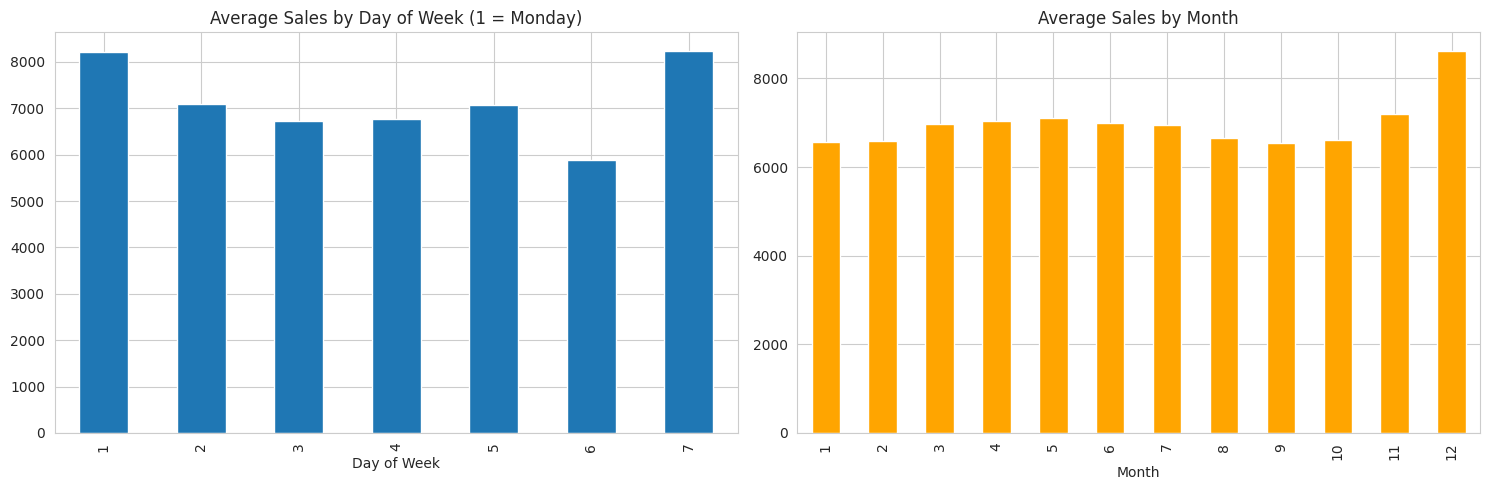

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

dow_summary = df.groupby("DayOfWeek")["Sales"].mean()
dow_summary.plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Sales by Day of Week (1 = Monday)")
axes[0].set_xlabel("Day of Week")

month_summary = df.groupby("Month")["Sales"].mean()
month_summary.plot(kind="bar", ax=axes[1], color="orange")
axes[1].set_title("Average Sales by Month")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.show()


### 5.5 Sales vs. Competition Distance

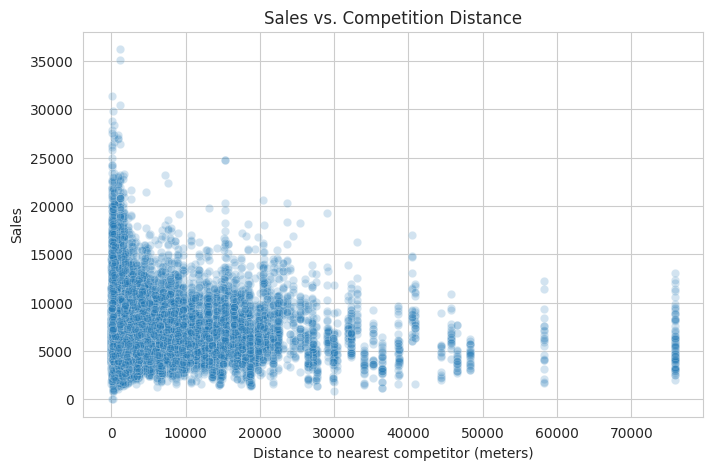

CompetitionDistanceBucket
<1km      7301.654210
1-5km     6836.022135
5-20km    6738.262574
>20km     6954.537689
Name: Sales, dtype: float64


In [18]:
plt.figure(figsize=(8, 5))
sample = df.sample(min(20000, len(df)), random_state=42)  # sample for a readable scatter
sns.scatterplot(x="CompetitionDistance", y="Sales", data=sample, alpha=0.2)
plt.title("Sales vs. Competition Distance")
plt.xlabel("Distance to nearest competitor (meters)")
plt.show()

# Bucket competition distance to see the relationship more clearly
df["CompetitionDistanceBucket"] = pd.cut(
    df["CompetitionDistance"],
    bins=[0, 1000, 5000, 20000, df["CompetitionDistance"].max()],
    labels=["<1km", "1-5km", "5-20km", ">20km"]
)
comp_summary = df.groupby("CompetitionDistanceBucket", observed=True)["Sales"].mean()
print(comp_summary)


## 6. Summary of Key EDA Findings

**Dataset scale:** 1,017,209 daily sales records across 1,115 stores, merged with store attributes into an 18-column dataset. No duplicate rows or duplicate Store/Date combinations were found. 172,817 rows were closed-store days (Sales == 0 in every case, confirming Open == 0 always implies Sales == 0), and these were dropped, leaving 844,392 rows for analysis.

**Missing data:** Promo2SinceWeek/Year and PromoInterval were missing in exactly the same 508,031 rows (49.9%), and this lines up perfectly with Promo2 == 0, confirming these fields are structurally missing (not a data quality issue) for stores that do not run the extended promotion. CompetitionOpenSinceMonth/Year were missing for 31.8% of rows, and CompetitionDistance for only 0.26%.

- **Promotions:** Promo days average 8,228 in sales versus 5,929 on non-promo days, a lift of roughly 39%. This is a strong, consistent signal that promotions are associated with materially higher sales, and it justifies Part 2's deeper look at whether this lift holds evenly across store types and conditions.

- **Store type:** Store type B stands out sharply, averaging 10,231 in sales versus roughly 6,800-6,900 for types A, C, and D. However, type B represents only 15,563 of the 844,392 rows (about 1.8%), so this gap likely reflects a small set of high-volume locations rather than a broad pattern, worth flagging for Part 2's feature selection.

- **Holidays:** State holidays show higher average sales (8,487-9,888 across holiday types a/b/c) than regular days (6,954), though these categories have very few observations (71-694 rows each) compared to 843,482 non-holiday rows, so this should be treated as a directional signal, not a robust estimate. School holidays show a smaller but consistent lift (7,200 vs. 6,897).

- **Seasonality:** Average sales are highest on Mondays (8,216) and Sundays (8,225, though very few stores open on Sundays after filtering) and lowest midweek (Wednesday-Thursday, roughly 6,700-6,770). By month, December stands out clearly (8,609), consistent with holiday shopping, while January and September are the softest months (around 6,550-6,565).

- **Competition:** Stores within 1km of a competitor actually show the highest average sales (7,302), higher than stores 1-20km away (6,740-6,840). This is counterintuitive if competition were simply a drag on sales, and likely reflects that close competitors cluster in high-traffic urban areas, a hypothesis Part 2's statistical testing should investigate directly rather than reading the raw correlation at face value.

**Handoff to Part 2:** the cleaned dataset (844,392 rows, 21 columns) is saved to `data/processed/rossmann_cleaned.csv`. Part 2 (feature engineering, statistical analysis, and feature selection) should build on this file rather than re-cleaning from raw data. Key open questions for Part 2: does the promotion lift hold up under formal hypothesis testing and across store types/seasons, does the competition-distance pattern survive controlling for store type/location, and is Store Type B's outsized average driven by a handful of stores that need to be handled carefully in modeling.
